# Statistical Analysis of Wheat Yield: Evaluating Variety and Phytosanitary Treatment Effects

## Objective
The objective of this study is to evaluate the sensitivity of wheat yield (rdt) relative to different wheat varieties. Furthermore, we investigate the potential interaction effects between wheat varieties and phytosanitary treatments (phyto) to determine if the combined influence significantly impacts agricultural productivity

## Database Description

The analysis is based on the 'ble' (Wheat) dataset, which includes three primary variables:

- rdt: Wheat yield (measured in quintals per hectare);
- ble: Wheat variety (Categorical: A, B, C, D);
- phyto: Phytosanitary treatment (Binary: 1 if applied, 0 otherwise)

## Loading the `wheat` database


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

The “ble.txt” file contains wheat yields for 80 plots, broken down by wheat variety (V1, V2, V3, or V4).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ble = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ble.txt', sep=";", decimal='.')
ble.head()

,parcelle,variete,phyto,rdt
0,1,V1,Avec,5652
1,2,V1,Avec,5583
2,3,V1,Avec,5612
3,4,V1,Avec,5735
4,5,V1,Avec,5704


## One-Way ANOVA

Let's examine the effect of wheat variety on yield.

First, let's visualize the effect of variety by displaying these box plots:

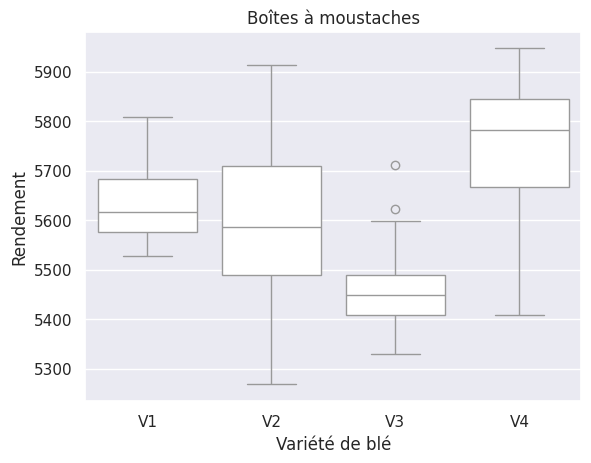

In [ ]:
sns.set()

ax = sns.boxplot(x="variete", y="rdt", data=ble, color='white')
plt.xlabel('Variété de blé')
plt.ylabel('Rendement')
plt.title('Boîtes à moustaches')
plt.show()

We observe that the average yields for the four variables (V1, V2, V3, and V4) differ significantly.
We therefore seek to determine whether these differences are statistically significant.

Let us now examine the effect of the presence or absence of pesticides on yield:

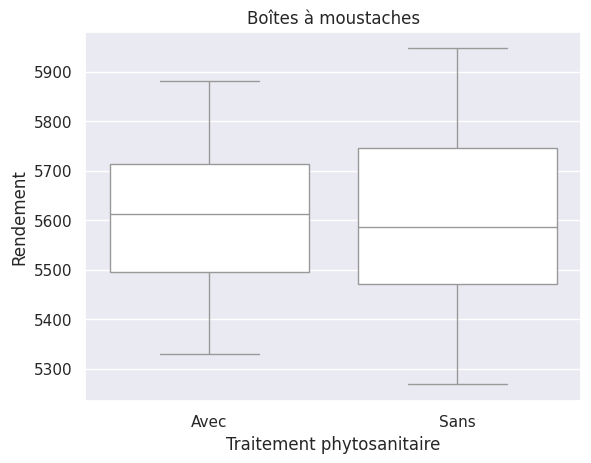

In [ ]:
ax = sns.boxplot(x="phyto", y="rdt", data=ble, color='white')
plt.xlabel('Traitement phytosanitaire')
plt.ylabel('Rendement')
plt.title('Boîtes à moustaches')
plt.show()

Here, we can see that the box plots are not very distinct, although there is slightly more variation in the "SANS pesticide” case.


Running the ANOVA to test the influence of wheat variety:

In [ ]:
anova_variete = smf.ols('rdt~variete', data=ble).fit()
print(anova_variete.summary())

                            OLS Regression Results                            
Dep. Variable:                    rdt   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     20.53
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           7.67e-10
Time:                        16:09:17   Log-Likelihood:                -492.86
No. Observations:                  80   AIC:                             993.7
Df Residuals:                      76   BIC:                             1003.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      5633.8000     26.300    214.211

This ANOVA test result provides us with the estimated parameters, but we cannot interpret them here. Instead, we will perform Fisher's exact test.

## Let's perform a Fisher's test

The p-value of this test ($7.67∗10^{-7}$) is very small and well below 5%. We therefore reject the null hypothesis H0 that the four varieties have equal average yields.


*The wheat variety does indeed have an effect on yield. This confirms the conclusion previously drawn after analyzing the box plots.*

One way ANOVA table

In [ ]:
sm.stats.anova_lm(anova_variete, typ=2)

,sum_sq,df,F,PR(>F)
variete,851844.55,3.0,20.525327,7.674413e-10
Residual,1051387.00,76.0,NaN,NaN


Let's now perform an analysis of variance on the pesticide used:

In [ ]:
anova_phyto = smf.ols('rdt~phyto', data=ble).fit()
print(anova_phyto.summary())

# ANOVA Table
sm.stats.anova_lm(anova_phyto, typ=2)

                            OLS Regression Results                            
Dep. Variable:                    rdt   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                   0.04134
Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.839
Time:                        16:24:07   Log-Likelihood:                -516.58
No. Observations:                  80   AIC:                             1037.
Df Residuals:                      78   BIC:                             1042.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      5612.2250     24.692    227.291

,sum_sq,df,F,PR(>F)
phyto,1008.20,1.0,0.041341,0.839411
Residual,1902223.35,78.0,NaN,NaN


After analyzing the ANOVA table, we observe that the p-value of 0.8 is greater than 0.5.
Therefore, we do not reject the null hypothesis H0, which states that wheat treated with pesticide and wheat treated without pesticide have equal average yields.

There is no significant effect of the pesticide on wheat yield.

## Two-way ANOVA

Let’s examine the influence of two factors (variety and pesticide) on wheat yield.

Let’s see if, for a specific variety, the pesticide has an effect on yield.

In [ ]:
anova_variete_phyto = smf.ols('rdt~variete*phyto', data=ble).fit()
print(anova_variete_phyto.summary())
sm.stats.anova_lm(anova_variete_phyto)

                            OLS Regression Results                            
Dep. Variable:                    rdt   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     8.458
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.62e-07
Time:                        16:38:22   Log-Likelihood:                -492.59
No. Observations:                  80   AIC:                             1001.
Df Residuals:                      72   BIC:                             1020.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

,df,sum_sq,mean_sq,F,PR(>F)
variete,3.0,851844.55,283948.183333,19.574935,2.205108e-09
phyto,1.0,1008.20,1008.200000,0.069504,7.928138e-01
variete:phyto,3.0,5968.20,1989.400000,0.137146,9.375236e-01
Residual,72.0,1044410.60,14505.702778,NaN,NaN


After analyzing the ANOVA table, we observe that the p-value for interactions (93.75%) is well above 5%; we can therefore conclude that interactions have no impact on yield.